Compare:
- $\xi_U$ with full anisotropic treatment, with `numpy.trapz` for integration
- $\xi_U$ with isotropic $\rho=(\rho_\parallel^2+2\rho_\perp^2)/3$, with `numpy.trapz` for integration
- $\xi_U$ with isotropic $\rho=(\rho_\parallel^2+2\rho_\perp^2)/3$, used in `Zeus21`, with `mcfit`

In [1]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

In [2]:
import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class

# Zeus setup

In [4]:
#and the user parameters
UserParams = zeus21.User_Parameters(precisionboost=1.2)

In [5]:
# cosmo inputs from table 2 last column of 1807.06209, as 21cmFAST
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

In [6]:
CosmoParams_input_aniso = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = True
    )
CosmoParams_input_corrected = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False, CORRECTED_XI_ETA=True
    )

ClassyCosmo_aniso = zeus21.runclass(CosmoParams_input_aniso)
ClassyCosmo_corrected = zeus21.runclass(CosmoParams_input_corrected)
print('CLASS has run, we store the cosmology.')

CLASS has run, we store the cosmology.


In [32]:
CosmoParams_input_zeus = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False, CORRECTED_XI_ETA=False
    )
ClassyCosmo_zeus = zeus21.runclass(CosmoParams_input_zeus)

In [44]:
#define all cosmology (including derived) parameters, and save them to the CosmoParams structure
CosmoParams_zeus = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input_zeus, ClassyCosmo_zeus)
CosmoParams_aniso = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input_aniso, ClassyCosmo_aniso)
CosmoParams_corrected = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input_corrected, ClassyCosmo_corrected)

#Generate and store the matter correlation function
# CorrFClass = zeus21.Correlations(UserParams, CosmoParams, ClassyCosmo)
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
CorrFClass_aniso = zeus21.Correlations(UserParams, CosmoParams_aniso, ClassyCosmo_aniso)
CorrFClass_corrected = zeus21.Correlations(UserParams, CosmoParams_corrected, ClassyCosmo_corrected)
print('Correlation functions saved.')

# Compute the HMF structure that stores associated quantities
HMFintclass_zeus = zeus21.HMF_interpolator(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
HMFintclass_aniso = zeus21.HMF_interpolator(UserParams, CosmoParams_aniso, ClassyCosmo_aniso)
HMFintclass_corrected = zeus21.HMF_interpolator(UserParams, CosmoParams_corrected, ClassyCosmo_corrected)
print('HMF interpolator built. This ends the cosmology part -- moving to astrophysics.')

Correlation functions saved.
HMF interpolator built. This ends the cosmology part -- moving to astrophysics.


In [45]:
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
CorrFClass_aniso = zeus21.Correlations(UserParams, CosmoParams_aniso, ClassyCosmo_aniso)
CorrFClass_corrected = zeus21.Correlations(UserParams, CosmoParams_corrected, ClassyCosmo_corrected)


In [46]:
### POP II quantities first

################################
### Model Parameters
astromodel = 0            # ASTRO MODEL: 0 for GALUMI-like, 1 for 21cmfast-like, default 0
accretion_model = 0       # ACCRETION MODEL: 0 for exponential, 1 for EPS, default EXP

################################
### SFR(Mh) Parameteres
alphastar = 0.5          # alphastar powerlaw index for low masses, default 0.5
betastar = -0.5           # betastar powerlaw index for high masses, default -0.5
epsstar = 10**-1.             # epsilonstar = fstar at Mc
Mc = 3e11                 # Pivot mass at which the power law cuts for model 0, default Mc = 3e11
dlog10epsstardz = 0.0     # dlog10epsilonstar/dz, default 0

################################
### Escape fraction parameters
fesc10 = 0.1              # fesc(M) parameter. Power law normalized (fesc10) at M=1e10 Msun with index alphaesc
alphaesc = 0.0
L40_xray = 10**0.5        # L40_xray: soft-band (E<2 keV) lum/SFR in Xrays in units of 10^40 erg/s/(Msun/yr)
E0_xray = 500.            # E0_xray: minimum energy in eV
alpha_xray = -1.0         # Xray SED power-law index
Emax_xray_norm=2000       # max energy in eV to normalize SED. Keep at 2000 eV normally

################################
### LyA parameters
Nalpha_lyA_II = 9690      # number of Pop II photons between LyA and Ly Cont. per baryon (from BL05)
Nalpha_lyA_III = 17900    # number of Pop III photons between LyA and Ly Cont. per baryon value of 17900 is from Klessen & Glover 2023 (2303.12500), table A2

################################
### MTURN Parameters: 
Mturn_fixed = None        # Mturn_fixed: None if use Matom(z) at each z, Some value if fixed Mturn
FLAG_MTURN_SHARP= False   # Mturn_sharp: False if regular exponential cutoff, True if sharp cutoff, active only if Mturn_fixed is on

################################
### UVLF Parameters
C0dust = 4.43             # DUST PARAMETERS FOR UVLFs
C1dust = 1.99
sigmaUV = 0.5             # stochasticity (gaussian rms) in the halo-galaxy connection P(MUV | Mh) - TODO: only used in UVLF not sfrd

################################
ZMIN = 10.0               # down to which z we compute the evolution



################################
# Pop III Quantities
alphastar_III = 0 
betastar_III = 0
fstar_III = 10**(-3.0)
Mc_III = 1e7
dlog10epsstardz_III = 0.0

fesc7_III = 10**(-1.35)
alphaesc_III = -0.3
L40_xray_III = 10**0.5
alpha_xray_III = -1.0


USE_POPIII = True
USE_LW_FEEDBACK = True

A_LW = 2.0
beta_LW = 0.6

A_vcb = 1.0
beta_vcb = 1.8


#set up your astro parameters too, here the peak of f*(Mh) as an example

AstroParams = zeus21.Astro_Parameters(UserParams,
                                      CosmoParams_zeus, 
                                      astromodel = astromodel, 
                                      accretion_model = accretion_model,
                                      
                                      alphastar = alphastar, 
                                      betastar = betastar, 
                                      epsstar = epsstar, 
                                      Mc = Mc, 
                                      dlog10epsstardz = dlog10epsstardz,
                                      
                                      fesc10 = fesc10, 
                                      alphaesc = alphaesc,
                                      L40_xray = L40_xray, 
                                      E0_xray = E0_xray, 
                                      alpha_xray = alpha_xray, 
                                      Emax_xray_norm = Emax_xray_norm, 
                                      
                                      Nalpha_lyA_II = Nalpha_lyA_II, 
                                      Nalpha_lyA_III = Nalpha_lyA_III,
                                      
                                      Mturn_fixed = Mturn_fixed, 
                                      FLAG_MTURN_SHARP = FLAG_MTURN_SHARP,

                                      C0dust = C0dust, 
                                      C1dust = C1dust,
                                      sigmaUV = sigmaUV,
                                     
                                     
                                      USE_POPIII = USE_POPIII, 
                                      USE_LW_FEEDBACK = USE_LW_FEEDBACK,

                                      alphastar_III = alphastar_III, 
                                      betastar_III = betastar_III,
                                      fstar_III = fstar_III,
                                      Mc_III = Mc_III,
                                      dlog10epsstardz_III = dlog10epsstardz_III,

                                      fesc7_III = fesc7_III,
                                      alphaesc_III = alphaesc_III,
                                      L40_xray_III = L40_xray_III,
                                      alpha_xray_III = alpha_xray_III,
                                               
                                      A_LW = A_LW,
                                      beta_LW = beta_LW,
                                      
                                      A_vcb = A_vcb,
                                      beta_vcb = beta_vcb
                                               )

# CoeffStructure = zeus21.get_T21_coefficients(UserParams, CosmoParams, ClassyCosmo, AstroParams, HMFintclass, zmin=ZMIN)
CoeffStructure_zeus = zeus21.get_T21_coefficients(UserParams, CosmoParams_zeus, ClassyCosmo_zeus, AstroParams, HMFintclass_zeus,
                                                    zmin=ZMIN)
CoeffStructure_aniso = zeus21.get_T21_coefficients(UserParams, CosmoParams_aniso, ClassyCosmo_aniso, AstroParams, HMFintclass_aniso,
                                                    zmin=ZMIN)
CoeffStructure_corrected = zeus21.get_T21_coefficients(UserParams, CosmoParams_corrected, ClassyCosmo_corrected, AstroParams, HMFintclass_corrected,
                                                    zmin=ZMIN)

print('SFRD and coefficients stored. Move ahead.')

SFRD and coefficients stored. Move ahead.


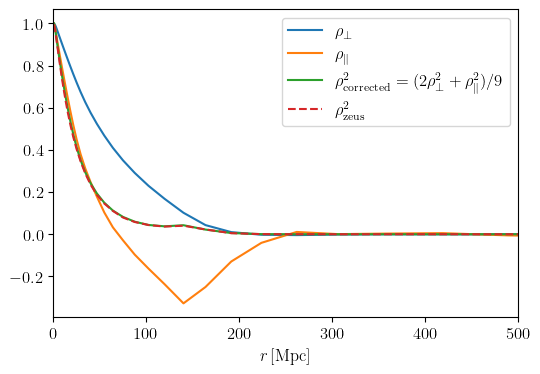

In [47]:
rlist = CorrFClass_aniso.rlist_CF
xiEta_para, xiEta_perp = CorrFClass_aniso.xiEta_RR_CF_para, CorrFClass_aniso.xiEta_RR_CF_perp
xiEta_corrected = CorrFClass_corrected.xiEta_RR_CF # ~ rho^2
xiEta_zeus = CorrFClass_zeus.xiEta_RR_CF # ~ rho^2, with mcfit

R1_choose = 0
R2_choose = 0

rho_para = xiEta_para[R1_choose, R2_choose, :,]
rho_perp = xiEta_perp[R1_choose, R2_choose, :,]
rho_sq_corrected = xiEta_corrected[R1_choose, R2_choose, :,] *3/2
rho_sq_zeus = xiEta_zeus[R1_choose, R2_choose, :,] *3/2

fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.plot(rlist, rho_perp, label=r'$\rho_{\perp}$')
ax.plot(rlist, rho_para, label=r'$\rho_{\parallel}$')
ax.plot(rlist, rho_sq_corrected, label=r'$\rho_{\mathrm{corrected}}^2=(2\rho_{\perp}^2 + \rho_{\parallel}^2)/9$')
ax.plot(rlist, rho_sq_zeus, linestyle='--', label=r'$\rho_{\mathrm{zeus}}^2$')
# ax.set_xlim(100, 1e4)
# ax.set_ylim(-1e-4, 1e-1)
# ax.set_xscale('log')
# ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlim(0, 500)
ax.set_xlabel(r'$r\,[\mathrm{Mpc}]$')
ax.legend()

In [48]:
_iRnonlinear = np.arange(CosmoParams_zeus.indexmaxNL)

vcbCoeffs1 = CoeffStructure_zeus.vcb_expFitParams[:, _iRnonlinear]
vcbCoeffsR1 = np.transpose(vcbCoeffs1, (2, 0, 1))
vcbCoeffsR1 = vcbCoeffsR1[:,:,:,np.newaxis,np.newaxis]
vcbCoeffsR2 = np.moveaxis(vcbCoeffsR1, 3, 2)

vcbCoeffsR1.shape, vcbCoeffsR2.shape

((4, 77, 34, 1, 1), (4, 77, 1, 34, 1))

In [49]:
zchoose = 30

In [50]:
Lambda1, lambda1, Omega1, omega1 = vcbCoeffsR1[:, zchoose, R1_choose, 0, 0]
Lambda2, lambda2, Omega2, omega2 = vcbCoeffsR2[:, zchoose, 0, R2_choose, 0]

In [51]:
lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)
xi_U_aniso = ((1 - lambda_term * rho_para**2) * (1 - lambda_term * rho_perp**2) ** 2) ** (-1/2) - 1
xi_U_corrected = (1 - lambda_term * rho_sq_corrected) ** (-3/2) - 1
xi_U_zeus = (1 - lambda_term * rho_sq_zeus) ** (-3/2) - 1

xi_U_aniso_normalized = xi_U_aniso / xi_U_aniso.max()
xi_U_corrected_normalized = xi_U_corrected / xi_U_corrected.max()
xi_U_zeus_normalized = xi_U_zeus / xi_U_zeus.max()

Text(0.5, 1.0, '$\\xi_U$')

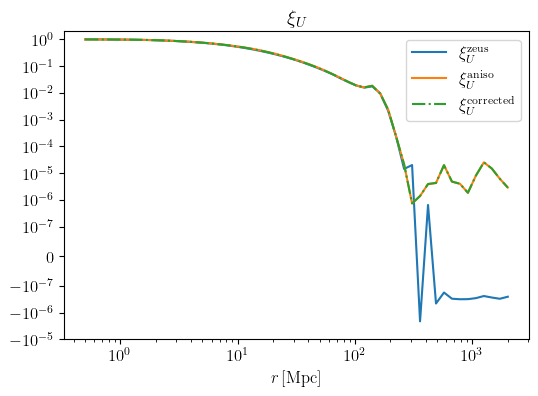

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rlist, xi_U_zeus_normalized, label=r'$\xi_U^{\mathrm{zeus}}$')
ax.plot(rlist, xi_U_aniso_normalized, label=r'$\xi_U^{\mathrm{aniso}}$')
ax.plot(rlist, xi_U_corrected_normalized, linestyle='-.', label=r'$\xi_U^{\mathrm{corrected}}$')
ax.legend()
ax.set_xscale('log')
ax.set_xlabel(r'$r\,[\mathrm{Mpc}]$')
ax.set_ylim(-1e-5, 2)
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_title(r'$\xi_U$')

Text(0.5, 1.0, 'fractional differences (zoomed into "flat" region)')

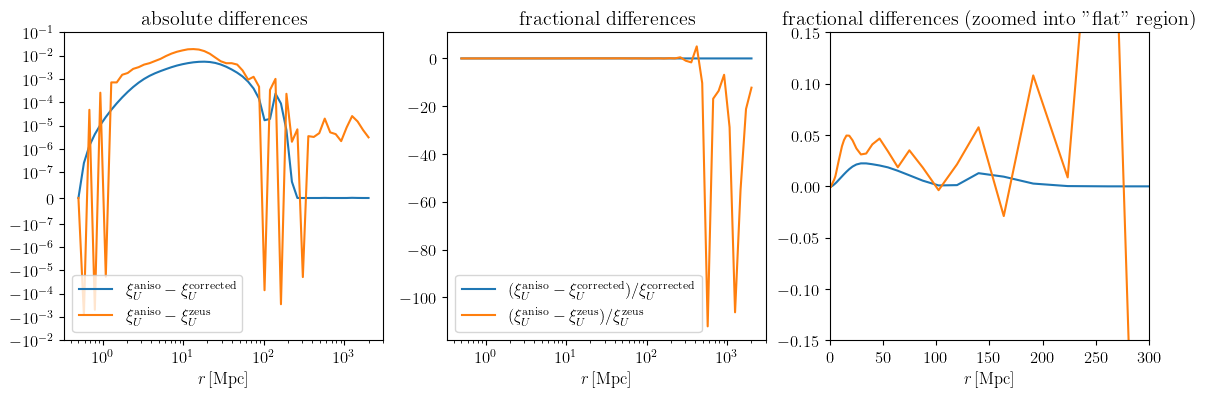

In [75]:
fig, axs = plt.subplots(1, 3, figsize=(14,4))
ax = axs[0]
# ax.plot(rlist, xi_U_aniso - xi_U_corrected, label=r'$\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{corrected}}$')
ax.plot(rlist, xi_U_aniso_normalized - xi_U_corrected_normalized, 
        label=r'$\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{corrected}}$')
ax.plot(rlist, xi_U_aniso_normalized - xi_U_zeus_normalized, 
        label=r'$\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{zeus}}$')

# ax.plot(rlist, xi_U_corrected, label=r'$\xi_U^{\mathrm{corrected}}$')
ax.legend()
# ax.set_xlim(0, 500)
ax.set_xscale('log')
ax.set_xlabel(r'$r\,[\mathrm{Mpc}]$')
ax.set_ylim(-1e-2, 1e-1)
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_title('absolute differences')

ax = axs[1]
ax.plot(rlist, (xi_U_aniso_normalized - xi_U_corrected_normalized) / xi_U_corrected_normalized, 
        label=r'$(\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{corrected}}) / \xi_U^{\mathrm{corrected}}$')
ax.plot(rlist, (xi_U_aniso_normalized - xi_U_zeus_normalized) / xi_U_zeus_normalized, 
        label=r'$(\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{zeus}}) / \xi_U^{\mathrm{zeus}}$')
ax.legend()
# ax.set_xlim(0, 500)
ax.set_xscale('log')
ax.set_xlabel(r'$r\,[\mathrm{Mpc}]$')
# ax.set_ylim(1-0.01, 1+0.01)
ax.set_title('fractional differences')

ax = axs[2]
ax.plot(rlist, (xi_U_aniso_normalized - xi_U_corrected_normalized) / xi_U_corrected_normalized, 
        label=r'$(\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{corrected}}) / \xi_U^{\mathrm{corrected}}$')
ax.plot(rlist, (xi_U_aniso_normalized - xi_U_zeus_normalized) / xi_U_zeus_normalized, 
        label=r'$(\xi_U^{\mathrm{aniso}} - \xi_U^{\mathrm{zeus}}) / \xi_U^{\mathrm{zeus}}$')
# ax.legend()
ax.set_xlim(0, 300)
# ax.set_xscale('log')
ax.set_xlabel(r'$r\,[\mathrm{Mpc}]$')
ax.set_ylim(-0.15, 0.15)
ax.set_title('fractional differences (zoomed into \"flat\" region)')

In [66]:
xi_U_zeus_normalized[-1]

np.float64(-2.541689107405365e-07)

In [53]:
RSDMODE = 1

PS21_zeus = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams, ClassyCosmo_zeus, CorrFClass_zeus, CoeffStructure, RSD_MODE = RSDMODE)
PS21_aniso = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams, ClassyCosmo_aniso, CorrFClass_aniso, CoeffStructure,
                                   RSD_MODE = RSDMODE)
PS21_corrected = zeus21.Power_Spectra(UserParams, CosmoParams, AstroParams, ClassyCosmo_corrected, CorrFClass_corrected, CoeffStructure,
                                   RSD_MODE = RSDMODE)

In [54]:
from scipy.interpolate import interp1d

xi_V_zeus = PS21_zeus._etaCorr_xa
xi_V_aniso = PS21_aniso._etaCorr_xa
xi_V_corrected = PS21_corrected._etaCorr_xa

# R1_choose = 0
# R2_choose = 0

xi_V_zeus_R1R2 = xi_V_zeus[:, R1_choose, R2_choose, :]
xi_V_aniso_R1R2 = xi_V_aniso[:, R1_choose, R2_choose, :]
# xi_V_R1R2_diff = xi_V_aniso_R1R2 - xi_V_R1R2
xi_V_R1R2_corrected = xi_V_corrected[:, R1_choose, R2_choose, :]

Nz = xi_V_zeus_R1R2.shape[0]
idxs = np.unique(np.linspace(0, Nz - 1, 5, dtype=int))

# Create a dense r grid for interpolation (log-spaced to preserve shape)
rlist_dense = np.logspace(np.log10(np.max([np.min(rlist[rlist>0]), 1e-3])), np.log10(np.max(rlist)), 300)

In [ ]:
zlist = CoeffStructure_zeus.zintegral

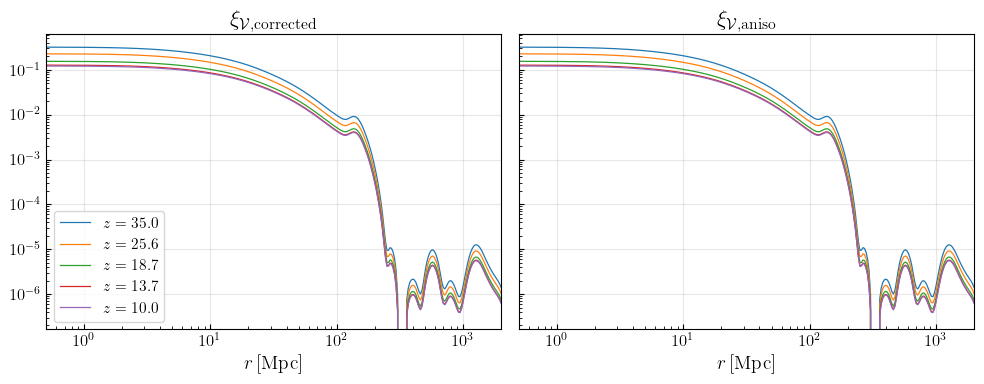

In [56]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

ax = axs[0]
for i in np.flip(idxs):
    # Interpolate in log-space for r > 0
    valid_idx = rlist > 0  # Avoid log(0)
    # interp_func_iso = interp1d(np.log10(rlist[valid_idx]), xi_V_R1R2[i, valid_idx], kind='cubic', fill_value="extrapolate")
    # iso_dense = interp_func_iso(np.log10(rlist_dense))
    # ax.plot(rlist_dense, iso_dense, linewidth=0.9, label=r"$z={:.1f}$".format(zlist[i]))
    interp_func_corrected = interp1d(np.log10(rlist[valid_idx]), xi_V_R1R2_corrected[i, valid_idx], kind='cubic', fill_value="extrapolate")
    corrected_dense = interp_func_corrected(np.log10(rlist_dense))
    ax.plot(rlist_dense, corrected_dense, linewidth=0.9, label=r"$z={:.1f}$".format(zlist[i]))
# ax.set_title(r'$\xi_{\mathcal{V},\mathrm{iso}}$', fontsize=16)
ax.set_title(r'$\xi_{\mathcal{V},\mathrm{corrected}}$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(2, 250)
# ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=14)
# ax.set_ylabel(r'$\Delta\xi_\mathcal{V}/\xi_{\mathcal{V},\mathrm{iso}}\,(r)$', fontsize=14)
ax.set_xlim(rlist_dense.min(), rlist_dense.max())
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", which="both", direction="in")
ax.legend(fontsize=11, title_fontsize=12, loc='lower left')

ax = axs[1]
for i in np.flip(idxs):
    # Interpolate in log-space for r > 0
    valid_idx = rlist > 0  # Avoid log(0)
    interp_func_aniso = interp1d(np.log10(rlist[valid_idx]), xi_V_aniso_R1R2[i, valid_idx], kind='cubic', fill_value="extrapolate")
    aniso_dense = interp_func_aniso(np.log10(rlist_dense))
    ax.plot(rlist_dense, aniso_dense, linewidth=0.9, label=r"$z={:.1f}$".format(zlist[i]))
ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_xlim(2, 250)
# ax.set_ylim(1e-6, 1e-1)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=14)
# ax.set_ylabel(r'$\Delta\xi_\mathcal{V}/\xi_{\mathcal{V},\mathrm{iso}}\,(r)$', fontsize=14)
ax.set_xlim(rlist_dense.min(), rlist_dense.max())
ax.grid(True, alpha=0.3)
ax.tick_params(axis="both", which="both", direction="in")
ax.set_title(r'$\xi_{\mathcal{V},\mathrm{aniso}}$', fontsize=16)

plt.tight_layout()

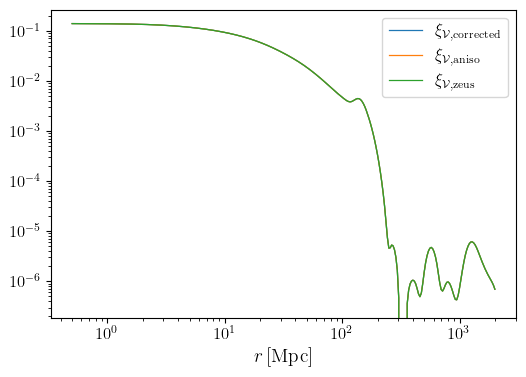

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

idxchoose = 30

interp_func_corrected = interp1d(np.log10(rlist), xi_V_R1R2_corrected[idxchoose, :], kind='cubic', fill_value="extrapolate")
corrected_dense = interp_func_corrected(np.log10(rlist_dense))
ax.plot(rlist_dense, corrected_dense, linewidth=0.9, 
        label=r'$\xi_{\mathcal{V},\mathrm{corrected}}$')

interp_func_aniso = interp1d(np.log10(rlist), xi_V_aniso_R1R2[idxchoose, :], kind='cubic', fill_value="extrapolate")
aniso_dense = interp_func_aniso(np.log10(rlist_dense))
ax.plot(rlist_dense, aniso_dense, linewidth=0.9, 
        label=r'$\xi_{\mathcal{V},\mathrm{aniso}}$')

interp_func_zeus = interp1d(np.log10(rlist), xi_V_zeus_R1R2[idxchoose, :], kind='cubic', fill_value="extrapolate")
zeus_dense = interp_func_zeus(np.log10(rlist_dense))
ax.plot(rlist_dense, zeus_dense, linewidth=0.9, 
        label=r'$\xi_{\mathcal{V},\mathrm{zeus}}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=14)
ax.legend()